In [1]:
import requests  # For sending HTTP requests
import json      # For handling JSON data
import os        # For accessing environment variables

# ==================== Configuration ====================
# Replace with your actual Mistral API key
API_KEY = os.getenv("MISTRAL_API_KEY")

# Base URL for Mistral's OpenAI-compatible chat completions endpoint
API_URL = "https://api.mistral.ai/v1/chat/completions"

# Choose one of the available models (e.g., 'mistral-tiny', 'mistral-small', 'mistral-medium')
MODEL = "mistral-medium"

# Headers for authentication and content type
HEADERS = {
    "Authorization": f"Bearer {API_KEY}",
    "Content-Type": "application/json"
}

# ==================== Function to Send a Chat Message ====================
def chat_with_mistral(messages):
    """
    Sends a list of messages to the Mistral chat API and returns the assistant's response.

    Parameters:
        messages (list): A list of message dictionaries in the OpenAI chat format.
                         Example: [{"role": "user", "content": "Hello!"}]

    Returns:
        str: The assistant's reply as a string.
    """
    payload = {
        "model": MODEL,
        "messages": messages,
        "temperature": 0.7,     # Creativity level (0 = deterministic, 1 = more random)
        "top_p": 1.0,           # Nucleus sampling parameter
        "stream": False         # Disable streaming for simple usage
    }

    # Send a POST request to Mistral's API
    response = requests.post(API_URL, headers=HEADERS, data=json.dumps(payload))

    # Raise an error if the request failed
    if response.status_code != 200:
        raise Exception(f"Request failed: {response.status_code} - {response.text}")

    # Parse the JSON response
    response_data = response.json()

    # Extract and return the assistant's reply
    return response_data['choices'][0]['message']['content']

In [2]:
if __name__ == "__main__":
    # Initialize a conversation with a greeting
    chat_history = [
        {"role": "user", "content": "Describe a woman"},
    ]

    try:
        # Send the message and receive the model's response
        response_woman = chat_with_mistral(chat_history)
        print(response_woman)
    except Exception as e:
        print("Error:", str(e))

Women are as diverse and multifaceted as humanity itself—no single description could ever capture the full spectrum of their identities, experiences, or essence. However, here’s a poetic and expansive reflection on the many dimensions a woman might embody:

---

A woman is **strength wrapped in vulnerability**—a paradox of resilience and tenderness. She is the quiet storm that reshapes landscapes and the gentle hand that mends what is broken. Her power is not always loud; sometimes it hums in the rhythm of her breath as she rises, again and again, from the weight of expectation or the echoes of doubt.

She is **creator and caretaker**, whether she births life, ideas, art, or movements. Her hands may cradle a child, a pen, a protest sign, or the soil of a garden—each act an extension of her capacity to nurture, to transform, to leave the world different than she found it.

She is **wisdom in motion**, carrying the stories of her ancestors in her bones and the dreams of future generation

In [7]:
import nltk
#nltk.download('wordnet') download wordnet

In [8]:
import matplotlib
from emoatlas import EmoScores
import emoatlas

In [9]:
emo = EmoScores(language='english')

**Emotional context**

In [ ]:
{k: emo.zscores(response_man).get(k, 0) + emo.zscores(response_woman).get(k, 0) for k in emo.zscores(response_man).keys() | emo.zscores(response_woman).keys()}

## USATO PER SOMMARE GLI Z SCORE

{'anger': -2.0036525452330247,
 'surprise': -0.5739287187413339,
 'joy': 5.272211916971853,
 'trust': 10.411270944308532,
 'fear': -3.5113248573708615,
 'anticipation': 1.9397269416849605,
 'sadness': -2.879052487705393,
 'disgust': -3.4298984873403002}


•	Calcolare il z-score emozionale di ogni testo permette di standardizzare le emozioni rispetto alla media e deviazione standard del campione, rendendo confrontabili i livelli emotivi tra testi diversi.
•	La somma dei z-score divisa per 100 (la media) dà un indice rappresentativo dell’emozione media nel gruppo di testi che descrivono uomini o donne.
•	Questo consente di confrontare in modo quantitativo e robusto il profilo emozionale medio tra le descrizioni di uomini e donne.
•	Puoi poi valutare statisticamente se le differenze medie emozionali sono significative (es. con test t).

In [15]:
emo.zscores(response_man) # It returns the z-scores for each emotion

{'anger': -2.214755314842832,
 'trust': 6.494584159676944,
 'surprise': 0.5500870076467362,
 'disgust': -2.1376589593301683,
 'joy': 1.4852816746776527,
 'sadness': -2.0047419832403084,
 'fear': -2.4384461375341417,
 'anticipation': -0.09693483073171538}

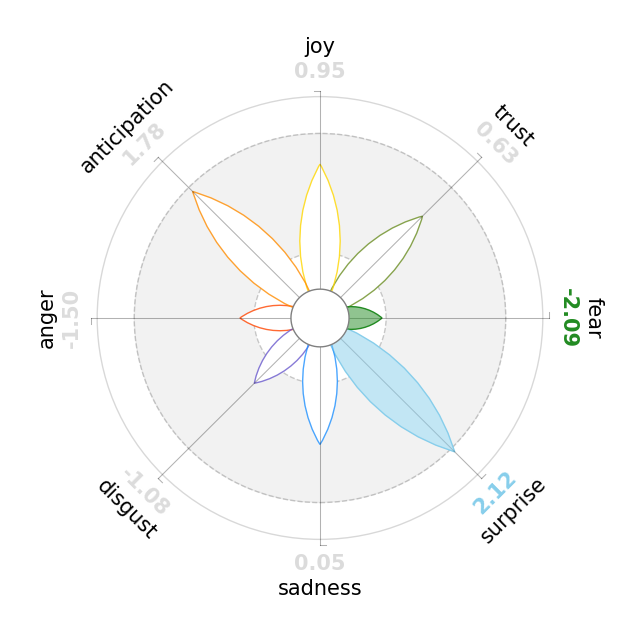

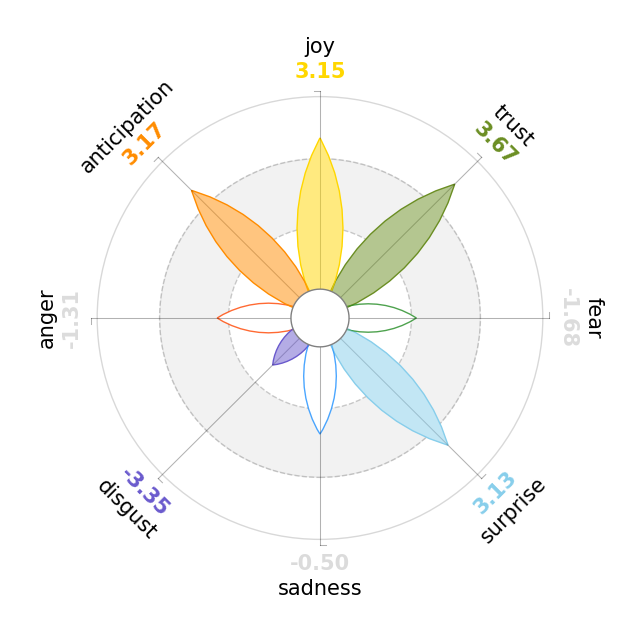

In [9]:
# Analyze the response for emotional content

fmnt_man = emo.formamentis_network(response_man)
emo.draw_statistically_significant_emotions(fmnt_man) #Plot satstistically significant emotions

fmnt_woman = emo.formamentis_network(response_woman)
emo.draw_statistically_significant_emotions(fmnt_woman) #Plot satstistically significant emotions

**Semantic frame analysis**

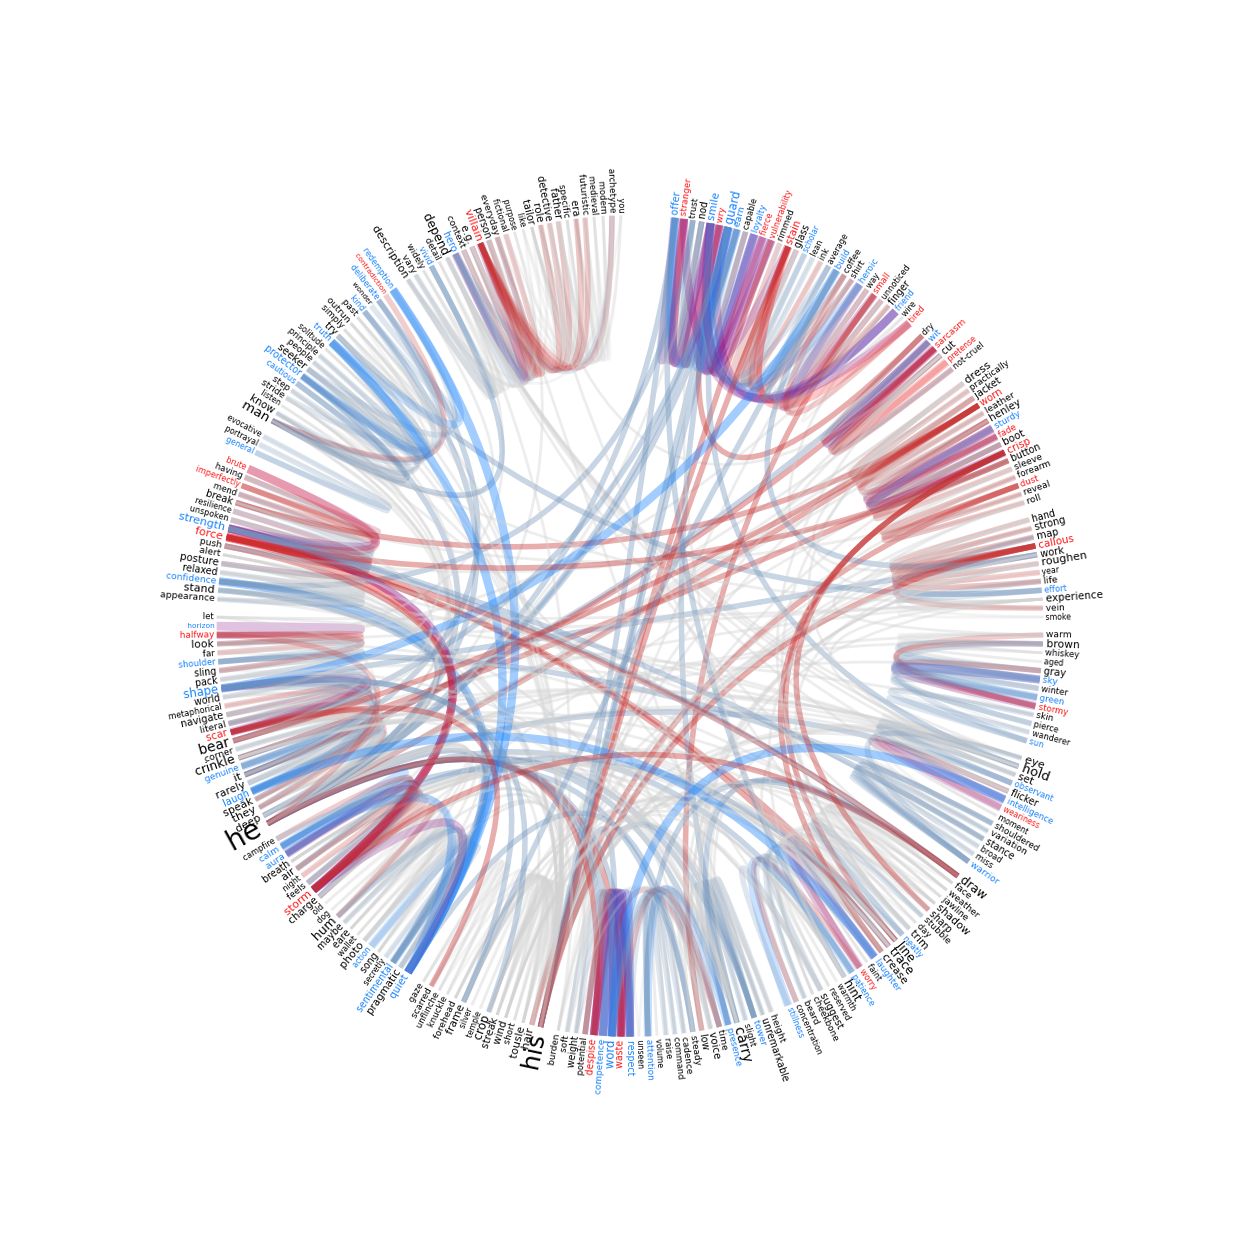

In [ ]:
# This network captures the syntactic and semantic relationships between all relevant words in the text.

emo.draw_formamentis(
    fmn=fmnt,
    alpha_syntactic=0.4,
    alpha_hypernyms=0,
    alpha_synonyms=0,
    thickness=2
)

Word's semantic frame analysis

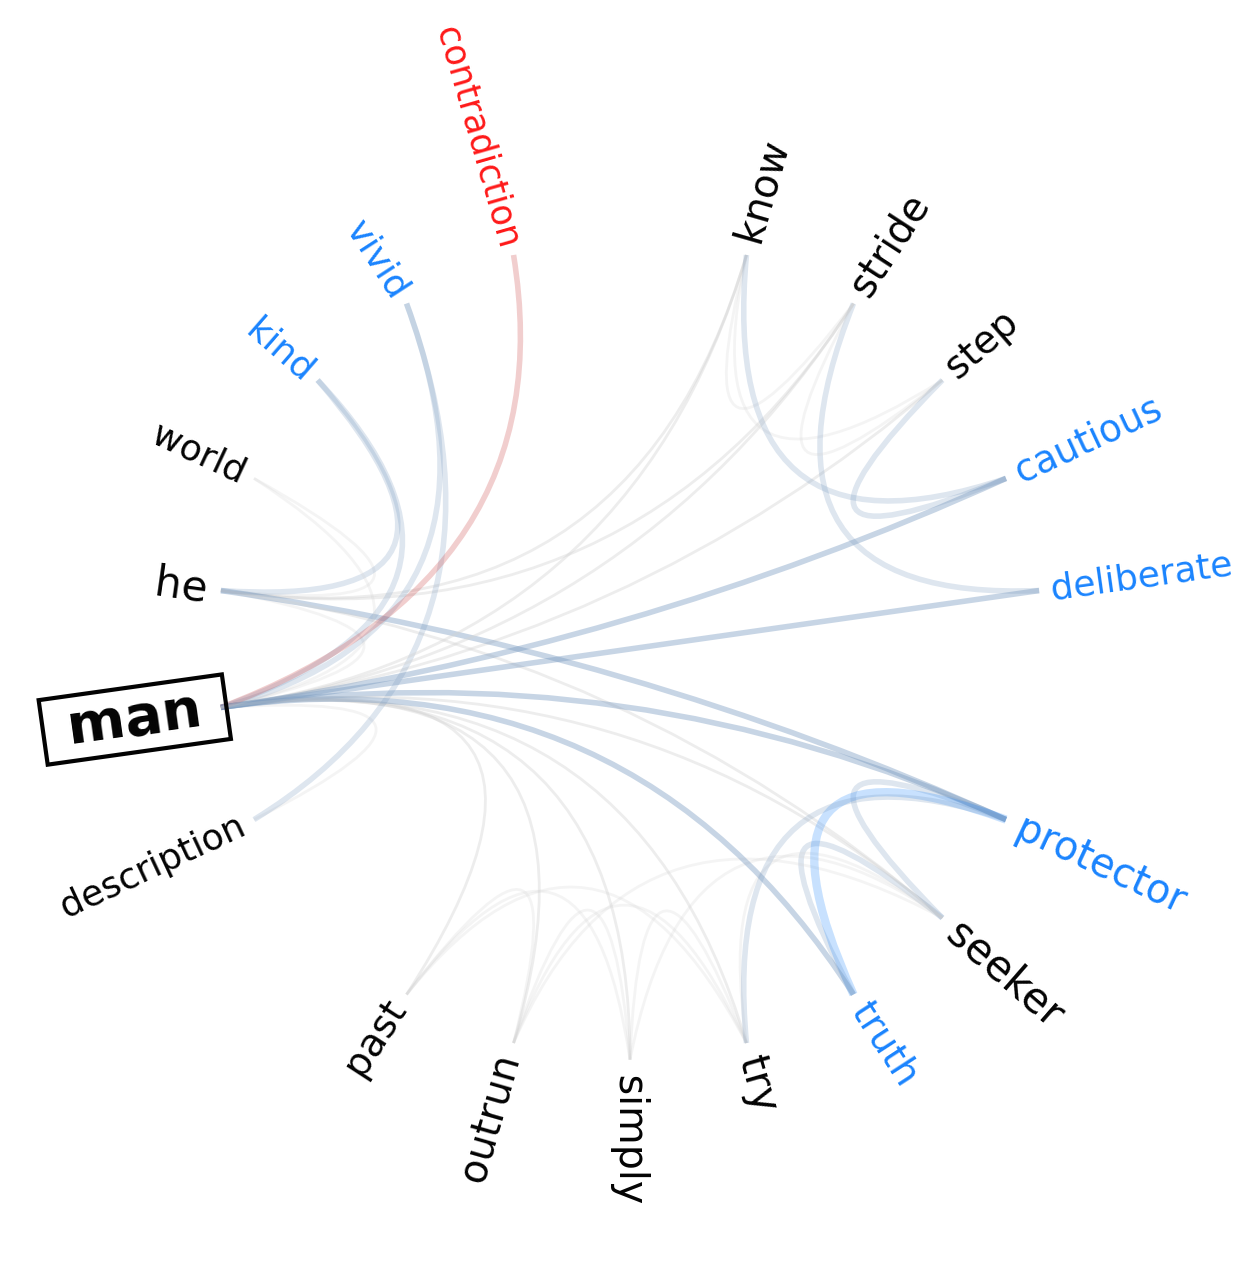

In [21]:
fmnt_man = emo.extract_word_from_formamentis(fmnt, "man")
emo.draw_formamentis(
    fmn=fmnt_man,
    highlight="failmanure",
    alpha_syntactic=0.4,
    alpha_hypernyms=0,
    alpha_synonyms=0,
    thickness=2
)

**TEST**

In [15]:
def collect_descriptions(prompt, num_descriptions=2):
    """
    Collects multiple descriptions using the Mistral API
    
    Parameters:
        prompt (str): The prompt to send to the API
        num_descriptions (int): Number of descriptions to collect
        
    Returns:
        list: List of descriptions
    """
    descriptions = []
    for i in range(num_descriptions):
        chat_history = [{"role": "user", "content": prompt}]
        try:
            response = chat_with_mistral(chat_history)
            descriptions.append(response)
            if i % 10 == 0:  # Print progress every 10 iterations
                print(f"Collected {i+1} descriptions")
        except Exception as e:
            print(f"Error on iteration {i}: {str(e)}")
            continue
    return descriptions

In [12]:
def analyze_emotional_content(descriptions):
    """
    Analyzes emotional content for a list of descriptions
    
    Parameters:
        descriptions (list): List of text descriptions
        
    Returns:
        list: List of emotional networks
    """
    emotional_networks = []
    for text in descriptions:
        fmnt = emo.formamentis_network(text)
        emotional_networks.append(fmnt)
    return emotional_networks

Collected 1 descriptions
Collected 1 descriptions


AttributeError: 'NoneType' object has no attribute 'items'

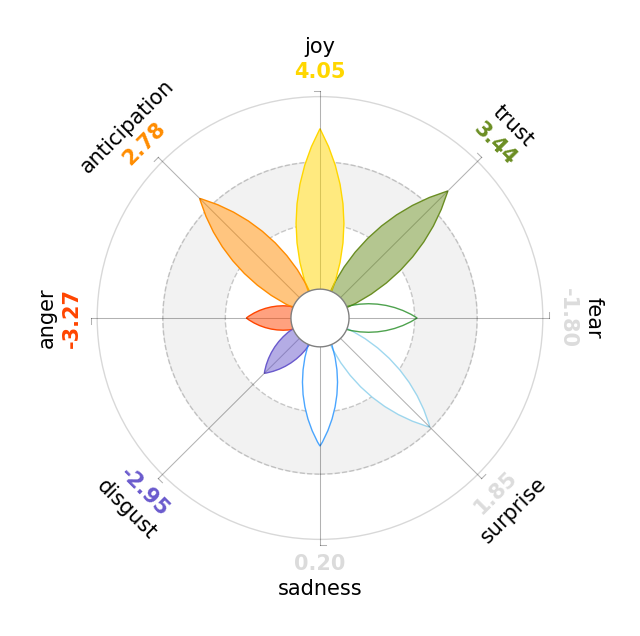

In [17]:
# Collect descriptions
man_descriptions = collect_descriptions("Describe a man")
woman_descriptions = collect_descriptions("Describe a woman")

# Analyze emotional content
man_networks = analyze_emotional_content(man_descriptions)
woman_networks = analyze_emotional_content(woman_descriptions)

# Calculate average emotional scores
def get_avg_emotional_scores(networks):
    total_scores = {}
    for network in networks:
        emotions = emo.draw_statistically_significant_emotions(network)
        for emotion, score in emotions.items():
            if emotion not in total_scores:
                total_scores[emotion] = []
            total_scores[emotion].append(score)
    
    avg_scores = {emotion: sum(scores)/len(scores) 
                 for emotion, scores in total_scores.items()}
    return avg_scores

man_avg_scores = get_avg_emotional_scores(man_networks)
woman_avg_scores = get_avg_emotional_scores(woman_networks)

# Plot comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
emotions = list(set(list(man_avg_scores.keys()) + list(woman_avg_scores.keys())))
x = range(len(emotions))

plt.bar([i-0.2 for i in x], [man_avg_scores.get(e, 0) for e in emotions], 
        width=0.4, label='Man', color='blue', alpha=0.6)
plt.bar([i+0.2 for i in x], [woman_avg_scores.get(e, 0) for e in emotions], 
        width=0.4, label='Woman', color='red', alpha=0.6)

plt.xticks(x, emotions, rotation=45)
plt.legend()
plt.title('Average Emotional Content Comparison')
plt.tight_layout()
plt.show()